Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            11 non-null     object 
 1   Gender             10 non-null     object 
 2   Married            10 non-null     object 
 3   Dependents         10 non-null     object 
 4   Education          11 non-null     object 
 5   Self_Employed      10 non-null     object 
 6   ApplicantIncome    11 non-null     int64  
 7   CoapplicantIncome  11 non-null     int64  
 8   LoanAmount         9 non-null      float64
 9   Loan_Amount_Term   10 non-null     float64
 10  Credit_History     9 non-null      float64
 11  Property_Area      11 non-null     object 
dtypes: float64(3), int64(2), object(7)
memory usage: 1.2+ KB

First 5 Rows:
  Loan_ID  Gender Married Dependents     Education Self_Employed  \
0   LP001    Male     Yes          0      Graduate       

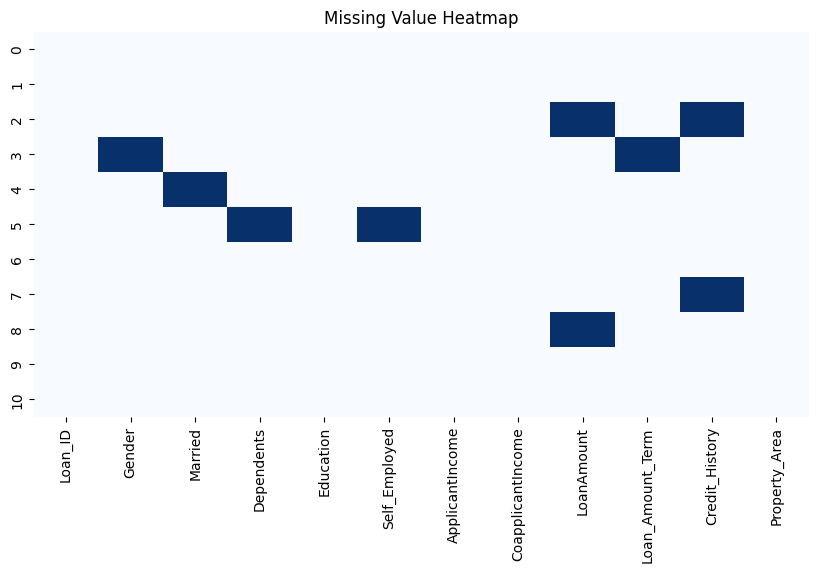


Missing Values After Filling:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Removed 1 duplicate rows.

Data Types After Conversion:
Loan_ID               object
Gender                object
Married               object
Dependents             int64
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

Categorical Values After Standardization:

 Gender
['Male' 'Female']

 Married
['Yes' 'No']

 Education
['Graduate' 'Not graduate']

 Self_Employed
['No' 'Yes']

 Property_Area
['Urban' 'Rural' 'Semiurban']

After Min-Max Scaling:
   ApplicantIncome  Coapplica

In [ ]:
# ============================================
# EXPERIMENT III: EDA - DATA CLEANING
# ============================================

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler


# ============================================
# 2. CREATE SAMPLE DATASET
# ============================================

data = {
    'Loan_ID': ['LP001', 'LP002', 'LP003', 'LP004', 'LP005',
                'LP006', 'LP007', 'LP008', 'LP009', 'LP010'],

    'Gender': ['Male', 'Female', 'Male', np.nan, 'Male',
               'Female', 'Male', 'Female', 'Male', 'Male'],

    'Married': ['Yes', 'No', 'Yes', 'Yes', np.nan,
                'No', 'Yes', 'No', 'Yes', 'Yes'],

    'Dependents': ['0', '1', '2', '3+', '0',
                   np.nan, '2', '1', '3+', '0'],

    'Education': ['Graduate', 'Graduate', 'Not Graduate',
                  'Graduate', 'Graduate', 'Not Graduate',
                  'Graduate', 'Graduate', 'Not Graduate', 'Graduate'],

    'Self_Employed': ['No', 'No', 'Yes', 'No', 'Yes',
                      np.nan, 'No', 'No', 'Yes', 'No'],

    'ApplicantIncome': [5000, 3000, 4000, 6000, 2500,
                        3500, 7000, 4500, 5500, 3200],

    'CoapplicantIncome': [1500, 0, 2000, 2500, 1000,
                          1200, 3000, 0, 1800, 1000],

    'LoanAmount': [200, 150, np.nan, 250, 120,
                   180, 300, 160, np.nan, 140],

    'Loan_Amount_Term': [360, 360, 360, np.nan, 180,
                         360, 360, 180, 360, 360],

    'Credit_History': [1, 1, np.nan, 1, 0,
                       1, 1, np.nan, 0, 1],

    'Property_Area': ['Urban', 'Rural', 'Semiurban', 'Urban',
                      'Rural', 'Semiurban', 'Urban', 'Rural',
                      'Semiurban', 'Urban']
}

df = pd.DataFrame(data)


# Add a duplicate row intentionally
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)


# ============================================
# 3. DISPLAY BASIC INFORMATION
# ============================================

print("Initial Data Overview:")
df.info()

print("\nFirst 5 Rows:")
print(df.head())


# ============================================
# 4. HANDLING MISSING VALUES
# ============================================

print("\nMissing Values in Each Column:")
print(df.isnull().sum())


# Missing Value Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")

plt.title("Missing Value Heatmap")
plt.show()


# Fill categorical columns with MODE
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:

    df[col] = df[col].fillna(df[col].mode()[0])


# Fill LoanAmount with MEDIAN
df['LoanAmount'] = df['LoanAmount'].fillna(
    df['LoanAmount'].median()
)


# Fill Loan_Amount_Term with MODE
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].mode()[0]
)


# Fill Credit_History with MODE
df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)


print("\nMissing Values After Filling:")
print(df.isnull().sum())


# ============================================
# 5. REMOVING DUPLICATES
# ============================================

initial_rows = df.shape[0]

df.drop_duplicates(inplace=True)

print(
    "\nRemoved",
    initial_rows - df.shape[0],
    "duplicate rows."
)


# ============================================
# 6. DATA TYPE CONVERSION
# ============================================

# Replace 3+ with 3
df['Dependents'] = df['Dependents'].replace('3+', '3')

# Convert Dependents to integer
df['Dependents'] = df['Dependents'].astype(int)

print("\nData Types After Conversion:")
print(df.dtypes)


# ============================================
# 7. ENSURING CATEGORICAL CONSISTENCY
# ============================================

categorical_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area'
]

for col in categorical_columns:

    df[col] = df[col].str.strip().str.capitalize()


print("\nCategorical Values After Standardization:")

for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())


# ============================================
# 8. MIN-MAX NORMALIZATION
# ============================================

min_max_scaler = MinMaxScaler()

scale_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
]

df[scale_cols] = min_max_scaler.fit_transform(
    df[scale_cols]
)

print("\nAfter Min-Max Scaling:")
print(df[scale_cols].head())


# ============================================
# 9. STANDARDIZATION
# ============================================

scaler = StandardScaler()

df[['Credit_History']] = scaler.fit_transform(
    df[['Credit_History']]
)

print("\nAfter Standardization:")
print(df[['Credit_History']].head())


# ============================================
# 10. FINAL OVERVIEW
# ============================================

print("\n============================================")
print("CLEANED DATA SUMMARY")
print("============================================")

df.info()

print("\nFirst 5 Rows of Cleaned Data:")
print(df.head())

print("\nFinal Missing Values:")
print(df.isnull().sum())


# ============================================
# RESULT
# ============================================

print("\nProgram was written and executed successfully.")